In [ ]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 57.1 MB/s eta 0:00:00


# Testing smaller Model


In [ ]:
import pandas as pd
import numpy as np
from gurobipy import Model, GRB

# -------------------------------------------------
# 1. Stroller data
# -------------------------------------------------

strollers = pd.DataFrame({
    "name":[
        "triv next","Vista V2","Cruz V2","Fox 3","Fox 5","Fox 5 (2 pieces)",
        "Mixx Next","City Mini GT2","Single-to-Double","Portable Playard",
        "Close2Baby","Breeze Plus Playard","Swivel Sleeper Luxe",
        "Smart Sleeper","Lullaby Playard","Travel Crib Light","Lotus Travel Crib"
    ],
    "L":[24,17.3,16.5,35,17.3,35,27,31,34,10.31,30,12,34,38,10.5,5,24],
    "W":[22.5,25.7,22.8,21,23.6,20.9,23.6,25.5,24.5,10.31,18,12,34,22,19,23.5,12],
    "H":[15,33,29.5,15,35.4,13.4,19,10.5,18,27.99,10,30,23,15.5,30,19,8],
    "weight":[18.4,27,25.5,21.8,21.1,28,28.3,22.4,27,14,30,23,32,38,25,13,14]
})

PADDING = 0.5

strollers["long"]  = np.maximum(strollers["L"], strollers["W"]) + PADDING
strollers["short"] = np.minimum(strollers["L"], strollers["W"]) + PADDING
strollers["height"]= strollers["H"] + PADDING


# -------------------------------------------------
# 2. Box catalog (YOUR DATA)
# -------------------------------------------------

boxes = pd.DataFrame({
"name":[
"Walmart Small","Walmart Medium","Walmart Large","Walmart Ext. Large",
"1","2","3","4","5","6","7","8","9","10","11","12","13","14","15","16","17",
"18","19","20","21",
"S-16765","S-4478","S-4659","S-4739","S-4803","S-21038","S-15043",
"S-4963","S-4190","S-22660","S-16785","S-4806","S-4866","S-4229",
"S-4417","S-4509","S-16766","S-4457"
],

"L":[
17,22,27,26,
10,12,12,14,15,15,16,40,18,20,20,20,24,24,24,24,30,
18,24,16,22,
36,36,24,24,24,24,25,26,26,28,28,28,28,30,30,30,40,36
],

"W":[
11,13,15,18,
10,12,12,14,12,15,16,40,18,12,20,20,18,18,24,24,24,
18,18,12,22,
24,36,24,20,20,24,16,26,26,24,24,20,28,20,24,24,30,36
],

"H":[
12,15,17,18,
10,6,12,14,10,48,4,40,18,12,12,20,6,18,16,24,6,
16,18,12,21.5,
18,24,36,16,18,30,16,20,26,12,20,24,20,20,12,24,30,18
]
})

# dimensional weight
boxes["dim_weight"] = (boxes["L"]*boxes["W"]*boxes["H"])/250


# -------------------------------------------------
# 3. Fit matrix
# -------------------------------------------------

fit = np.zeros((len(boxes),len(strollers)))

for i,b in boxes.iterrows():
    for j,s in strollers.iterrows():

        if (
            s["long"] <= b["L"] and
            s["short"] <= b["W"] and
            s["height"] <= b["H"]
        ):
            fit[i,j] = 1


# -------------------------------------------------
# 4. Build optimization model
# -------------------------------------------------

m = Model()

B = len(boxes)
S = len(strollers)

x = m.addVars(B,S,vtype=GRB.BINARY,name="assign")
y = m.addVars(B,vtype=GRB.BINARY,name="use_box")


# -------------------------------------------------
# 5. Constraints
# -------------------------------------------------

# each stroller assigned exactly one box
for j in range(S):
    m.addConstr(sum(x[i,j] for i in range(B)) == 1)

# assignment only if box used
for i in range(B):
    for j in range(S):
        m.addConstr(x[i,j] <= y[i])

# enforce fit
for i in range(B):
    for j in range(S):
        if fit[i,j] == 0:
            m.addConstr(x[i,j] == 0)

# choose at most 5 box types
m.addConstr(sum(y[i] for i in range(B)) <= 7)


# -------------------------------------------------
# 6. Shipping cost
# -------------------------------------------------

cost = {}

for i in range(B):
    for j in range(S):

        dim_w = boxes.loc[i,"dim_weight"]
        actual = strollers.loc[j,"weight"]

        shipping_w = max(dim_w, actual)

        cost[i,j] = shipping_w


m.setObjective(
    sum(cost[i,j]*x[i,j] for i in range(B) for j in range(S)),
    GRB.MINIMIZE
)

m.optimize()


# -------------------------------------------------
# 7. Results
# -------------------------------------------------

print("\nChosen box types:\n")

for i in range(B):
    if y[i].x > 0.5:
        print(boxes.loc[i])


print("\nAssignments:\n")

for j in range(S):
    for i in range(B):
        if x[i,j].x > 0.5:
            print(strollers.loc[j,"name"], "->", boxes.loc[i,"name"])

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1394 rows, 774 columns and 2881 nonzeros (Min)
Model fingerprint: 0x9a339b5e
Model has 731 linear objective coefficients
Variable types: 0 continuous, 774 integer (774 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+01, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 7e+00]

Found heuristic solution: objective 2738.8160000
Presolve removed 1331 rows and 704 columns
Presolve time: 0.00s
Presolved: 63 rows, 70 columns, 176 nonzeros
Found heuristic solution: objective 2626.8160000
Variable types: 0 continuous, 70 integer (70 binary)
Found heuristic solution: objective 2280.7040000

Root relaxation: objective 1.718016e+03, 21 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current

# Analysis

In [ ]:
# -------------------------------------------------
# Perfect baseline (best box per stroller)
# -------------------------------------------------

perfect_results = []

for j, s in strollers.iterrows():

    best_cost = float("inf")
    best_box = None

    for i, b in boxes.iterrows():

        if fit[i,j] == 1:

            dim_w = b["dim_weight"]
            actual = s["weight"]

            shipping_weight = max(dim_w, actual)

            if shipping_weight < best_cost:
                best_cost = shipping_weight
                best_box = b["name"]

    perfect_results.append({
        "stroller": s["name"],
        "perfect_box": best_box,
        "perfect_shipping_weight": best_cost
    })

perfect_df = pd.DataFrame(perfect_results)

In [ ]:
perfect_df

,stroller,perfect_box,perfect_shipping_weight
0,triv next,S-16785,53.760
1,Vista V2,8,256.000
2,Cruz V2,S-21038,69.120
3,Fox 3,S-16765,62.208
4,Fox 5,8,256.000
5,Fox 5 (2 pieces),S-16765,62.208
6,Mixx Next,S-4866,62.720
7,City Mini GT2,S-4457,93.312
8,Single-to-Double,S-4478,124.416
9,Portable Playard,6,43.200


In [ ]:
opt_results = []

for j in range(S):
    for i in range(B):

        if x[i,j].x > 0.5:

            dim_w = boxes.loc[i,"dim_weight"]
            actual = strollers.loc[j,"weight"]

            ship_w = max(dim_w, actual)

            opt_results.append({
                "stroller": strollers.loc[j,"name"],
                "box": boxes.loc[i,"name"],
                "box_L": boxes.loc[i,"L"],
                "box_W": boxes.loc[i,"W"],
                "box_H": boxes.loc[i,"H"],
                "optimized_shipping_weight": ship_w
            })

opt_df = pd.DataFrame(opt_results)

In [ ]:
comparison = opt_df.merge(perfect_df,on="stroller")

comparison["extra_shipping_weight"] = (
    comparison["optimized_shipping_weight"]
    - comparison["perfect_shipping_weight"]
)

print(comparison)

               stroller      box  box_L  box_W  box_H  \
0             triv next  S-16765     36     24   18.0   
1              Vista V2        8     40     40   40.0   
2               Cruz V2   S-4659     24     24   36.0   
3                 Fox 3  S-16765     36     24   18.0   
4                 Fox 5        8     40     40   40.0   
5      Fox 5 (2 pieces)  S-16765     36     24   18.0   
6             Mixx Next   S-4866     28     28   20.0   
7         City Mini GT2   S-4478     36     36   24.0   
8      Single-to-Double   S-4478     36     36   24.0   
9      Portable Playard        6     15     15   48.0   
10           Close2Baby  S-16765     36     24   18.0   
11  Breeze Plus Playard        6     15     15   48.0   
12  Swivel Sleeper Luxe   S-4478     36     36   24.0   
13        Smart Sleeper  S-16766     40     30   30.0   
14      Lullaby Playard   S-4659     24     24   36.0   
15    Travel Crib Light   S-4866     28     28   20.0   
16    Lotus Travel Crib  S-1676

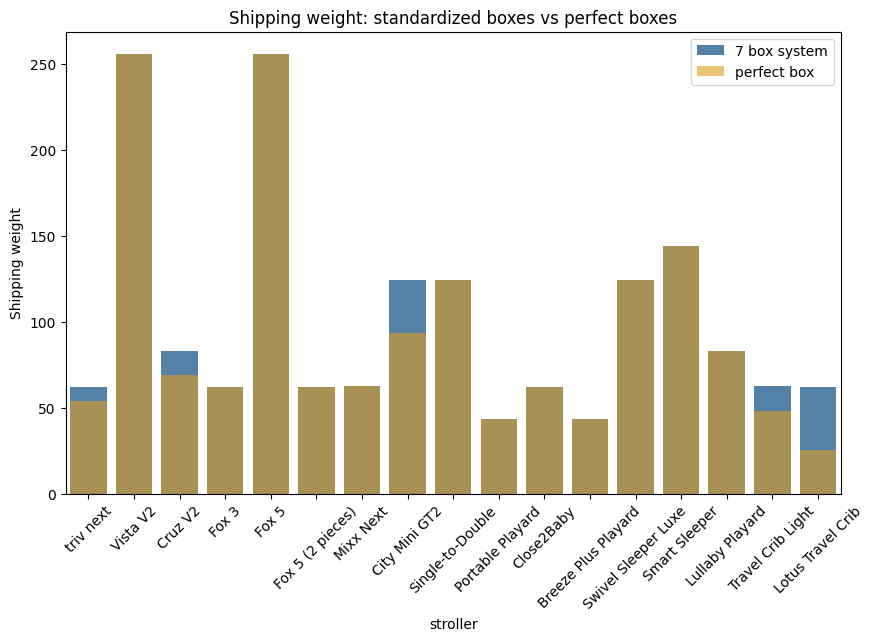

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="stroller",
    y="optimized_shipping_weight",
    color="steelblue",
    label="7 box system"
)

sns.barplot(
    data=comparison,
    x="stroller",
    y="perfect_shipping_weight",
    color="orange",
    alpha=0.6,
    label="perfect box"
)

plt.xticks(rotation=45)
plt.ylabel("Shipping weight")
plt.title("Shipping weight: standardized boxes vs perfect boxes")
plt.legend()

plt.show()

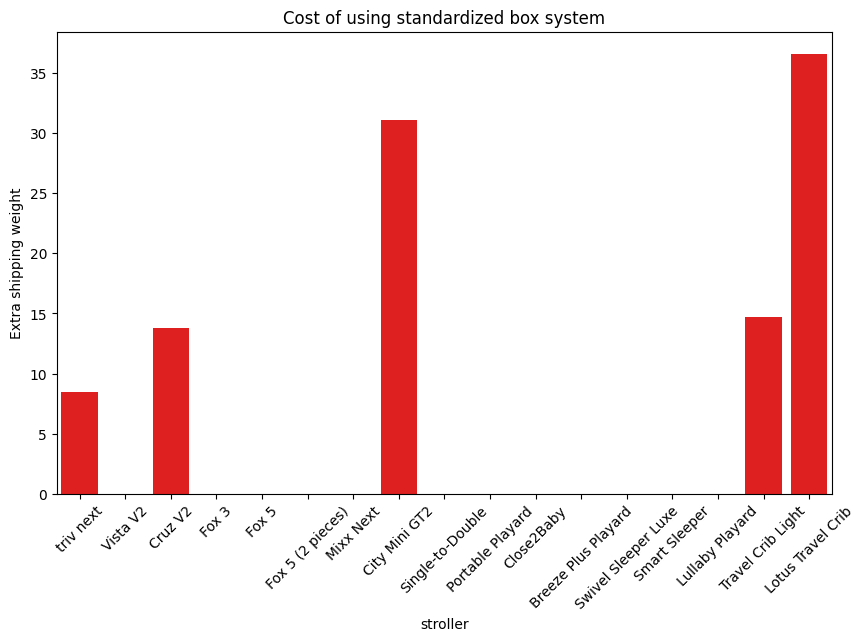

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="stroller",
    y="extra_shipping_weight",
    color="red"
)

plt.xticks(rotation=45)
plt.ylabel("Extra shipping weight")
plt.title("Cost of using standardized box system")

plt.show()

In [ ]:
print("\nTotal optimized shipping weight:",
      comparison["optimized_shipping_weight"].sum())

print("Total perfect shipping weight:",
      comparison["perfect_shipping_weight"].sum())

print("Total penalty from standardization:",
      comparison["extra_shipping_weight"].sum())


Total optimized shipping weight: 1718.016
Total perfect shipping weight: 1613.312
Total penalty from standardization: 104.70400000000001
